# **Using MRI for Brain Tumor Detection and Segmentation**

This notebook contains the code to process the BraTS 2020 data, and implement an Attention UNet model for brain tumor segmentation. It has been adapted from the *Brain Tumor Segmentation using U-Net* notebook code found on Kaggle: https://www.kaggle.com/code/zeeshanlatif/brain-tumor-segmentation-using-u-net/notebook#14

## **Dataset Information**
The Brain Tumor Segmentation (BraTS) 2020 dataset is a collection of multimodal Magnetic Resonance Imaging (MRI) scans used for the segmentation of brain tumors.

It includes MRI scans from glioma patients, providing four different MRI modalities:

1. **T1**
2. **T1ce**: Post-contrast T1-weighted
3. **T2**
4. **FLAIR**: T2 Fluid Attenuated Inversion Recovery

These scans come with expert-annotated segmentation masks that delineate the tumor into various sub-regions, such as the necrotic and non-enhancing tumor core, the peritumoral edema, and the enhancing tumor.

Annotations (labels):
1. **Label 0:** Not Tumor (NT) volume
2. **Label 1:** Necrotic and non-enhancing tumor core (NCR/NET)
3. **Label 2:** Peritumoral edema (ED)
4. **Label 3:** GD-enhancing tumor (ET)

## **Load and Explore Dataset**

In [ ]:
import os
import cv2
import random
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps
import nibabel as nib
import keras
import tensorflow.keras.backend as K
from keras.callbacks import CSVLogger
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard

import csv
import scipy.ndimage as ndi
import matplotlib.colors as mcolors

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Create distribution strategy (for Kaggle with 2 GPUs)
strategy = tf.distribute.MirroredStrategy()
print('Number of devices: {}'.format(strategy.num_replicas_in_sync))

Number of devices: 1


In [ ]:
Train_Path = "/content/drive/MyDrive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

In [ ]:
# Load .nii files as numpy arrays
test_image_flair = nib.load(Train_Path + "BraTS20_Training_306/BraTS20_Training_306_flair.nii").get_fdata()
print("Shape: ", test_image_flair.shape)
print("Dtype: ", test_image_flair.dtype)

# Rescale images
scaler = MinMaxScaler()
test_image_flair = scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)

# rescaling t1
test_image_t1 = nib.load(Train_Path + 'BraTS20_Training_306/BraTS20_Training_306_t1.nii').get_fdata()
test_image_t1 = scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

# rescaling t1ce
test_image_t1ce = nib.load(Train_Path + 'BraTS20_Training_306/BraTS20_Training_306_t1ce.nii').get_fdata()
test_image_t1ce = scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

# rescaling t2
test_image_t2 = nib.load(Train_Path + 'BraTS20_Training_306/BraTS20_Training_306_t2.nii').get_fdata()
test_image_t2 = scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

# no rescale for mask
test_image_seg = nib.load(Train_Path + 'BraTS20_Training_306/BraTS20_Training_306_seg.nii').get_fdata()

Shape:  (240, 240, 155)
Dtype:  float64


Slice Number: 95


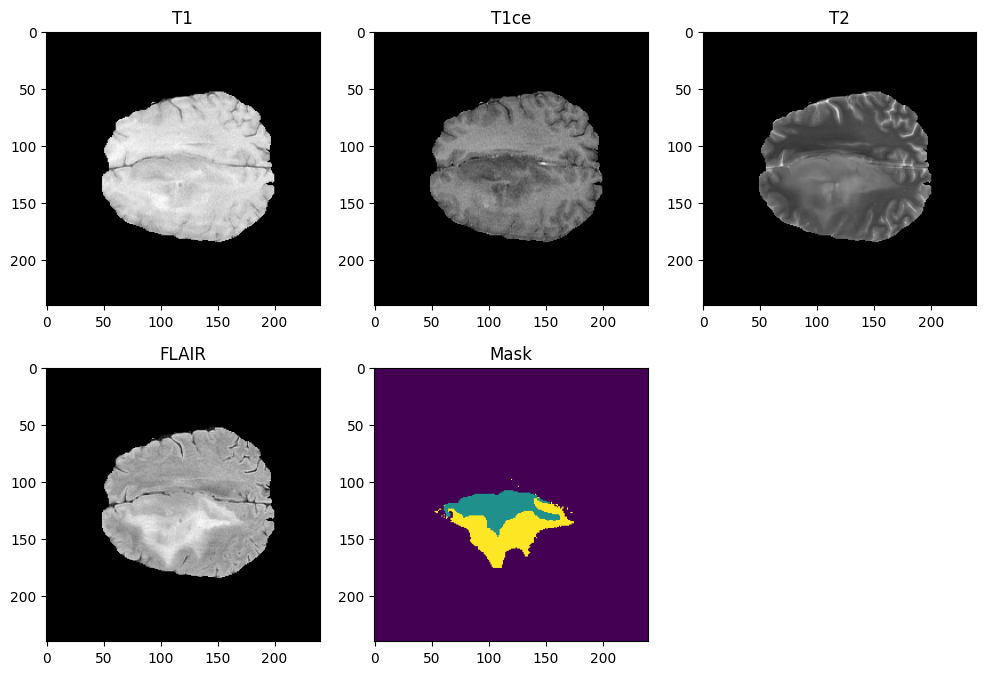

In [ ]:
slice = 95

print("Slice Number: " + str(slice))

plt.figure(figsize=(12, 8))

# T1
plt.subplot(2, 3, 1)
plt.imshow(test_image_t1[:,:,slice], cmap='gray')
plt.title('T1')

# T1ce
plt.subplot(2, 3, 2)
plt.imshow(test_image_t1ce[:,:,slice], cmap='gray')
plt.title('T1ce')

# T2
plt.subplot(2, 3, 3)
plt.imshow(test_image_t2[:,:,slice], cmap='gray')
plt.title('T2')

# Flair
plt.subplot(2, 3, 4)
plt.imshow(test_image_flair[:,:,slice], cmap='gray')
plt.title('FLAIR')

# Mask
plt.subplot(2, 3, 5)
plt.imshow(test_image_seg[:,:,slice])
plt.title('Mask')
plt.show()

cmap = matplotlib.colors.ListedColormap(['#440054', '#3b528b', '#18b880', '#e6d74f'])
norm = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

In [ ]:
# Modality shape
print("Modality: ", test_image_t1.shape)

# Segmentation shape
print("Segmentation: ", test_image_seg.shape)

Modality:  (240, 240, 155)
Segmentation:  (240, 240, 155)


Slice number: 95


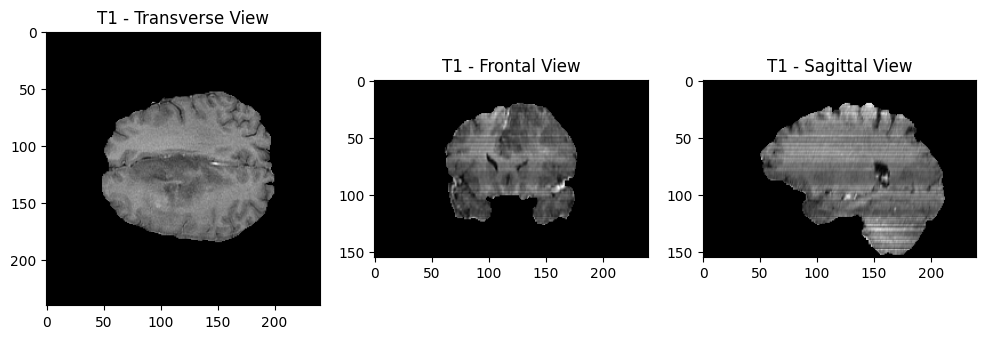

In [ ]:
slice = 95

print("Slice number: " + str(slice))

plt.figure(figsize=(12, 8))

# T1 - Transverse View
plt.subplot(1, 3, 1)
plt.imshow(test_image_t1ce[:,:,slice], cmap='gray')
plt.title('T1 - Transverse View')

# T1 - Frontal View
plt.subplot(1, 3, 2)
plt.imshow(rotate(test_image_t1ce[:,slice,:], 90, resize=True), cmap='gray')
plt.title('T1 - Frontal View')

# T1 - Sagittal View
plt.subplot(1, 3, 3)
plt.imshow(rotate(test_image_t1ce[slice,:,:], 90, resize=True), cmap='gray')
plt.title('T1 - Sagittal View')
plt.show()

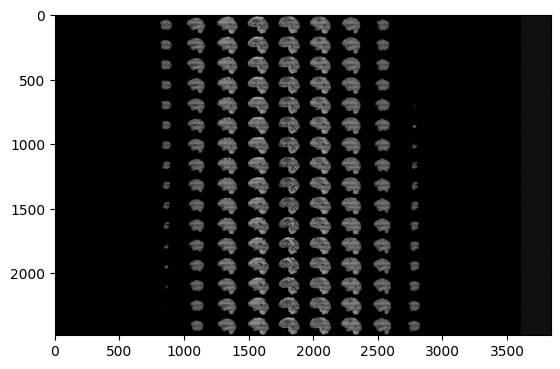

In [ ]:
# Montage
plt.imshow(rotate(montage(test_image_t1ce[:,:,:]), 90, resize=True), cmap ='gray');

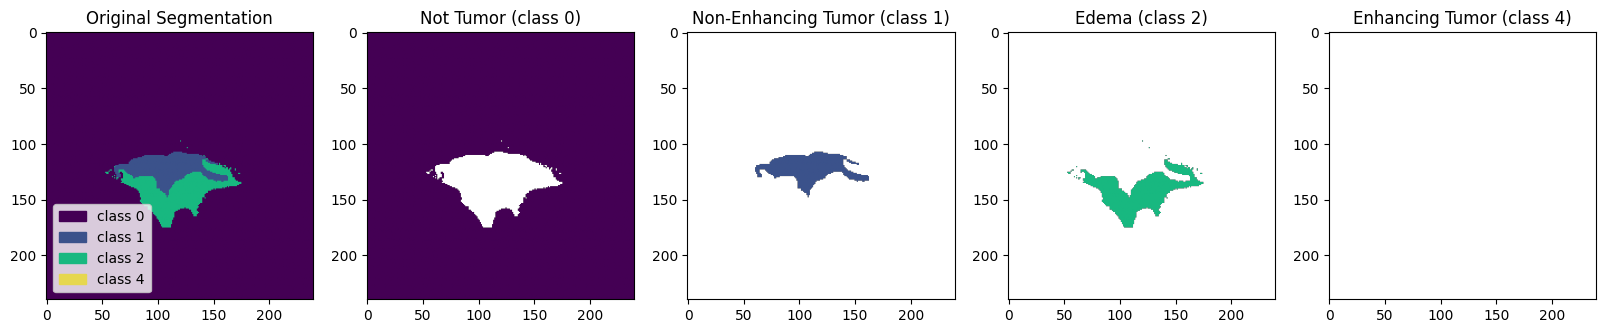

In [ ]:
# Isolation of class 0
seg_0 = test_image_seg.copy()
seg_0[seg_0 != 0] = np.nan

# Isolation of class 1
seg_1 = test_image_seg.copy()
seg_1[seg_1 != 1] = np.nan

# Isolation of class 2
seg_2 = test_image_seg.copy()
seg_2[seg_2 != 2] = np.nan

# Isolation of class 4
seg_4 = test_image_seg.copy()
seg_4[seg_4 != 4] = np.nan

# Define legend
class_names = ['class 0', 'class 1', 'class 2', 'class 4']
legend = [plt.Rectangle((0, 0), 1, 1, color=cmap(i), label=class_names[i]) for i in range(len(class_names))]

fig, ax = plt.subplots(1, 5, figsize=(20, 20))

ax[0].imshow(test_image_seg[:,:, slice], cmap=cmap, norm=norm)
ax[0].set_title('Original Segmentation')
ax[0].legend(handles=legend, loc='lower left')

ax[1].imshow(seg_0[:,:, slice], cmap=cmap, norm=norm)
ax[1].set_title('Not Tumor (class 0)')

ax[2].imshow(seg_1[:,:, slice], cmap=cmap, norm=norm)
ax[2].set_title('Non-Enhancing Tumor (class 1)')

ax[3].imshow(seg_2[:,:, slice], cmap=cmap, norm=norm)
ax[3].set_title('Edema (class 2)')

ax[4].imshow(seg_4[:,:, slice], cmap=cmap, norm=norm)
ax[4].set_title('Enhancing Tumor (class 4)')

plt.show()

## **Splitting the Data**

* **Training Set:** 70%
* **Validation Set:** 20%
* **Testing Set:** 10%

In [ ]:
# Load ids from csv files
train_ids_df = pd.read_csv("/content/drive/MyDrive/Baseline_UNet/train_subjects.csv")
val_ids_df = pd.read_csv("/content/drive/MyDrive/Baseline_UNet/validation_subjects.csv")
test_ids_df = pd.read_csv("/content/drive/MyDrive/Baseline_UNet/test_subjects.csv")

# Convert to lists
train_ids = train_ids_df.iloc[:, 0].astype(str).tolist()
val_ids = val_ids_df.iloc[:, 0].astype(str).tolist()
test_ids = test_ids_df.iloc[:, 0].astype(str).tolist()

# Sanity check
print(f"Train length: {len(train_ids)}")
print(f"Validation length: {len(val_ids)}")
print(f"Test length: {len(test_ids)}")

Train length: 258
Validation length: 74
Test length: 37


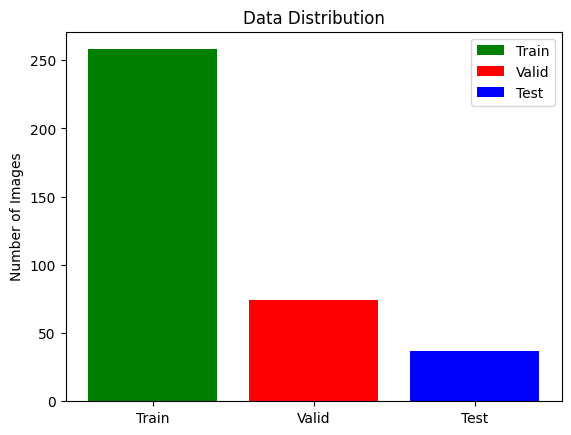

In [ ]:
plt.bar(["Train","Valid","Test"],
        [len(train_ids), len(val_ids), len(test_ids)],
        align='center',
        color=[ 'green','red', 'blue'],
        label=["Train", "Valid", "Test"]
       )

plt.legend()

plt.ylabel('Number of Images')
plt.title('Data Distribution')

plt.show()

## **DataGenerator**
1. Retrieve paths
2. Load data
3. Create arrays

Additional preprocessing steps include:
* Axial plane
* One-Hot Encoding
* Resize images

In [ ]:
# Define seg-areas
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE',
    2 : 'EDEMA',
    3 : 'ENHANCING'
}

# Select Slices and Image Size
VOLUME_SLICES = 100
VOLUME_START_AT = 22
IMG_SIZE=128

In [ ]:
class DataGenerator(keras.utils.Sequence):
    """Generates data for Keras."""
    def __init__(self, list_IDs, dim=(IMG_SIZE, IMG_SIZE), batch_size=4, n_channels=4, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        "Denotes the number of batches per epoch (using ceil to include the last partial batch)"
        return int(np.ceil(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        "Generate one batch of data"
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        Batch_ids = [self.list_IDs[k] for k in indexes]
        X, Y = self.__data_generation(Batch_ids)
        #print("Batch max value:", np.max(X))
        return X, Y

    def on_epoch_end(self):
        "Updates indexes after each epoch"
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        "Generates data containing batch_size samples"
        batch_size_actual = len(Batch_ids)
        # Initialize X to hold each slice for each case
        X = np.zeros((batch_size_actual * VOLUME_SLICES, *self.dim, self.n_channels), dtype=np.float32)
        # y is initially defined with shape (batch_size * VOLUME_SLICES, 240, 240)
        y = np.zeros((batch_size_actual * VOLUME_SLICES, 240, 240), dtype=np.int32)

        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(Train_Path, i)

            t1 = nib.load(os.path.join(case_path, f'{i}_t1.nii')).get_fdata()
            t2 = nib.load(os.path.join(case_path, f'{i}_t2.nii')).get_fdata()
            flair = nib.load(os.path.join(case_path, f'{i}_flair.nii')).get_fdata()
            t1ce = nib.load(os.path.join(case_path, f'{i}_t1ce.nii')).get_fdata()
            seg = nib.load(os.path.join(case_path, f'{i}_seg.nii')).get_fdata()

            for j in range(VOLUME_SLICES):
                slice_index = j + VOLUME_START_AT
                # Rezise T1 and T2
                X[j + VOLUME_SLICES * c, :, :, 0] = cv2.resize(t1[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
                X[j + VOLUME_SLICES * c, :, :, 2] = cv2.resize(t2[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
                # Resize the flair and t1ce images to (IMG_SIZE, IMG_SIZE)
                X[j + VOLUME_SLICES * c, :, :, 1] = cv2.resize(flair[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
                X[j + VOLUME_SLICES * c, :, :, 3] = cv2.resize(t1ce[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
                # Resize the segmentation to 240x240 (if needed)
                y[j + VOLUME_SLICES * c] = cv2.resize(seg[:, :, slice_index], (240, 240))

        # Replace label 4 with 3 in the segmentation
        y[y == 4] = 3
        # Convert y to one-hot encoding with 4 classes
        mask = tf.one_hot(y, 4)
        # Resize mask to (IMG_SIZE, IMG_SIZE) for each slice
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

        # Normalize X safely (avoid division by zero)
        max_val = np.max(X)
        if max_val != 0:
            X = X / max_val
        return X, Y

# Usage:
training_generator = DataGenerator(train_ids, batch_size=4, n_channels=4)
valid_generator = DataGenerator(val_ids, batch_size=4, n_channels=4)
test_generator = DataGenerator(test_ids, batch_size=4, n_channels=4)

## **Loss Function and Evaluation Metrics**

In [ ]:
# DiceCoefMetric (for all classes)
class DiceCoefMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes=4, smooth=1.0, name='dice_coef', **kwargs):
        super(DiceCoefMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.smooth = smooth
        self.total_dice = self.add_weight(name='total_dice', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        dice_sum = 0.0
        for i in range(self.num_classes):
            y_true_f = tf.reshape(y_true[..., i], [-1])
            y_pred_f = tf.reshape(y_pred[..., i], [-1])
            intersection = tf.reduce_sum(y_true_f * y_pred_f)
            dice = (2. * intersection + self.smooth) / (
                tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + self.smooth)
            dice_sum += dice
        dice_avg = dice_sum / self.num_classes
        self.total_dice.assign_add(dice_avg)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_dice / self.count

    def reset_states(self):
        self.total_dice.assign(0.0)
        self.count.assign(0.0)

# DiceCoefNecroticMetric
class DiceCoefNecroticMetric(tf.keras.metrics.Metric):
    def __init__(self, smooth=1e-6, name='dice_coef_necrotic', **kwargs):
        super(DiceCoefNecroticMetric, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.total_dice = self.add_weight(name='total_dice_necrotic', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_channel = tf.reshape(y_true[..., 1], [-1])
        y_pred_channel = tf.reshape(y_pred[..., 1], [-1])
        intersection = tf.reduce_sum(tf.abs(y_true_channel * y_pred_channel))
        dice = (2. * intersection) / (
            tf.reduce_sum(tf.square(y_true_channel)) + tf.reduce_sum(tf.square(y_pred_channel)) + self.smooth)
        self.total_dice.assign_add(dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_dice / self.count

    def reset_states(self):
        self.total_dice.assign(0.0)
        self.count.assign(0.0)

# DiceCoefEdemaMetric
class DiceCoefEdemaMetric(tf.keras.metrics.Metric):
    def __init__(self, smooth=1e-6, name='dice_coef_edema', **kwargs):
        super(DiceCoefEdemaMetric, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.total_dice = self.add_weight(name='total_dice_edema', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_channel = tf.reshape(y_true[..., 2], [-1])
        y_pred_channel = tf.reshape(y_pred[..., 2], [-1])
        intersection = tf.reduce_sum(y_true_channel * y_pred_channel)
        dice = (2. * intersection) / (
            tf.reduce_sum(tf.square(y_true_channel)) + tf.reduce_sum(tf.square(y_pred_channel)) + self.smooth)
        self.total_dice.assign_add(dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_dice / self.count

    def reset_states(self):
        self.total_dice.assign(0.0)
        self.count.assign(0.0)

# DiceCoefEnhancingMetric
class DiceCoefEnhancingMetric(tf.keras.metrics.Metric):
    def __init__(self, smooth=1e-6, name='dice_coef_enhancing', **kwargs):
        super(DiceCoefEnhancingMetric, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.total_dice = self.add_weight(name='total_dice_enhancing', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_channel = tf.reshape(y_true[..., 3], [-1])
        y_pred_channel = tf.reshape(y_pred[..., 3], [-1])
        intersection = tf.reduce_sum(tf.abs(y_true_channel * y_pred_channel))
        dice = (2. * intersection) / (
            tf.reduce_sum(tf.square(y_true_channel)) + tf.reduce_sum(tf.square(y_pred_channel)) + self.smooth)
        self.total_dice.assign_add(dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_dice / self.count

    def reset_states(self):
        self.total_dice.assign(0.0)
        self.count.assign(0.0)

# PrecisionMetric
class PrecisionMetric(tf.keras.metrics.Metric):
    def __init__(self, name='precision', **kwargs):
        super(PrecisionMetric, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.predicted_positives = self.add_weight(name='pp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true_pred = tf.round(tf.clip_by_value(y_true * y_pred, 0, 1))
        y_pred_rounded = tf.round(tf.clip_by_value(y_pred, 0, 1))
        tp = tf.reduce_sum(y_true_pred)
        pp = tf.reduce_sum(y_pred_rounded)
        self.true_positives.assign_add(tp)
        self.predicted_positives.assign_add(pp)

    def result(self):
        return self.true_positives / (self.predicted_positives + tf.keras.backend.epsilon())

    def reset_states(self):
        self.true_positives.assign(0.0)
        self.predicted_positives.assign(0.0)

# SensitivityMetric (Recall)
class SensitivityMetric(tf.keras.metrics.Metric):
    def __init__(self, name='sensitivity', **kwargs):
        super(SensitivityMetric, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.possible_positives = self.add_weight(name='pp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true_pred = tf.round(tf.clip_by_value(y_true * y_pred, 0, 1))
        y_true_rounded = tf.round(tf.clip_by_value(y_true, 0, 1))
        tp = tf.reduce_sum(y_true_pred)
        pp = tf.reduce_sum(y_true_rounded)
        self.true_positives.assign_add(tp)
        self.possible_positives.assign_add(pp)

    def result(self):
        return self.true_positives / (self.possible_positives + tf.keras.backend.epsilon())

    def reset_states(self):
        self.true_positives.assign(0.0)
        self.possible_positives.assign(0.0)

# SpecificityMetric
class SpecificityMetric(tf.keras.metrics.Metric):
    def __init__(self, name='specificity', **kwargs):
        super(SpecificityMetric, self).__init__(name=name, **kwargs)
        self.true_negatives = self.add_weight(name='tn', initializer='zeros')
        self.possible_negatives = self.add_weight(name='pn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        one_minus_y_true = 1 - y_true
        one_minus_y_pred = 1 - y_pred
        tn = tf.reduce_sum(tf.round(tf.clip_by_value(one_minus_y_true * one_minus_y_pred, 0, 1)))
        pn = tf.reduce_sum(tf.round(tf.clip_by_value(one_minus_y_true, 0, 1)))
        self.true_negatives.assign_add(tn)
        self.possible_negatives.assign_add(pn)

    def result(self):
        return self.true_negatives / (self.possible_negatives + tf.keras.backend.epsilon())

    def reset_states(self):
        self.true_negatives.assign(0.0)
        self.possible_negatives.assign(0.0)

## **Define Attention UNet Segmentation Model**

In [ ]:
from tensorflow.keras.layers import Multiply, Conv2D, Activation

def attention_gate(x, g, inter_channel):
    """Attention gate for U-Net (Oktay et al., 2018)."""
    theta_x = Conv2D(inter_channel, (1, 1), strides=(1, 1), padding='same')(x)
    phi_g = Conv2D(inter_channel, (1, 1), strides=(1, 1), padding='same')(g)

    f = Activation('relu')(theta_x + phi_g)
    psi = Conv2D(1, (1, 1), strides=(1, 1), padding='same')(f)
    sigmoid = Activation('sigmoid')(psi)

    return Multiply()([x, sigmoid])  # Apply attention weights

In [ ]:
def build_unet(inputs, ker_init, dropout):
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs)
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1)

    pool = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3)


    pool4 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool4)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv5)
    drop5 = Dropout(dropout)(conv5)

#added attention gates to decoder
    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(drop5))
    att7 = attention_gate(conv3, up7, 256)
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv7))
    att8 = attention_gate(conv2, up8, 128)
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv8))
    att9 = attention_gate(conv, up9, 64)
    merge9 = concatenate([conv,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv9)

    up = Conv2D(32, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv9))
    att = attention_gate(conv1, up, 32)
    merge = concatenate([conv1,up], axis = 3)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)

    conv10 = Conv2D(4, (1,1), activation = 'softmax')(conv)

    return Model(inputs = inputs, outputs = conv10)

In [ ]:
# Build model
with strategy.scope():
    input_layer = tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 4))
    model = build_unet(input_layer, 'he_normal', 0.2)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        metrics=[
            'accuracy',
            tf.keras.metrics.MeanIoU(num_classes=4),
            DiceCoefMetric(),
            DiceCoefNecroticMetric(),
            DiceCoefEdemaMetric(),
            DiceCoefEnhancingMetric(),
            PrecisionMetric(),
            SensitivityMetric(),
            SpecificityMetric()
        ]
    )

In [ ]:
# Set Up Callbacks
callbacks = [
      keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                            patience=2, min_lr=0.000001, verbose=1),
      keras.callbacks.ModelCheckpoint(filepath='model_.{epoch:02d}-{val_loss:.6f}.weights.h5',
                                verbose=1, save_best_only=True, save_weights_only=True),
      CSVLogger('/content/drive/MyDrive/AUNet/training.log', separator=',', append=False)
    ]

## **Train and Save the Model**


In [ ]:
history = model.fit(
    training_generator,
    epochs=25,
    callbacks=callbacks,
    validation_data=valid_generator
)
model.save("/content/drive/MyDrive/AUNet/AUNet.keras")

Epoch 1/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9831 - dice_coef: 0.2381 - dice_coef_edema: 0.0651 - dice_coef_enhancing: 0.0301 - dice_coef_necrotic: 0.0269 - loss: 0.2860 - mean_io_u: 0.4567 - precision: 0.9825 - sensitivity: 0.8924 - specificity: 0.9947 
Epoch 1: val_loss improved from inf to 0.07577, saving model to model_.01-0.075770.weights.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 3399s 52s/step - accuracy: 0.9831 - dice_coef: 0.2384 - dice_coef_edema: 0.0656 - dice_coef_enhancing: 0.0303 - dice_coef_necrotic: 0.0271 - loss: 0.2839 - mean_io_u: 0.4568 - precision: 0.9825 - sensitivity: 0.8935 - specificity: 0.9947 - val_accuracy: 0.9832 - val_dice_coef: 0.2683 - val_dice_coef_edema: 0.0807 - val_dice_coef_enhancing: 0.0450 - val_dice_coef_necrotic: 0.0347 - val_loss: 0.0758 - val_mean_io_u: 0.4645 - val_precision: 0.9831 - val_sensitivity: 0.9831 - val_specificity: 0.9944 - learning_rate: 3.0000e-04
Epoch 2/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9836 - dice_c

## **Load Trained Model**

In [ ]:
model = keras.models.load_model(
    '/content/drive/MyDrive/AUNet/AUNet.keras',
    custom_objects={
        "accuracy": tf.keras.metrics.MeanIoU(num_classes=4),
        "dice_coef": DiceCoefMetric,
        "dice_coef_necrotic": DiceCoefNecroticMetric,
        "dice_coef_edema": DiceCoefEdemaMetric,
        "dice_coef_enhancing": DiceCoefEnhancingMetric,
        "precision": PrecisionMetric,
        "sensitivity": SensitivityMetric,
        "specificity": SpecificityMetric
    },
    compile=False
)

## **Metrics Analysis**

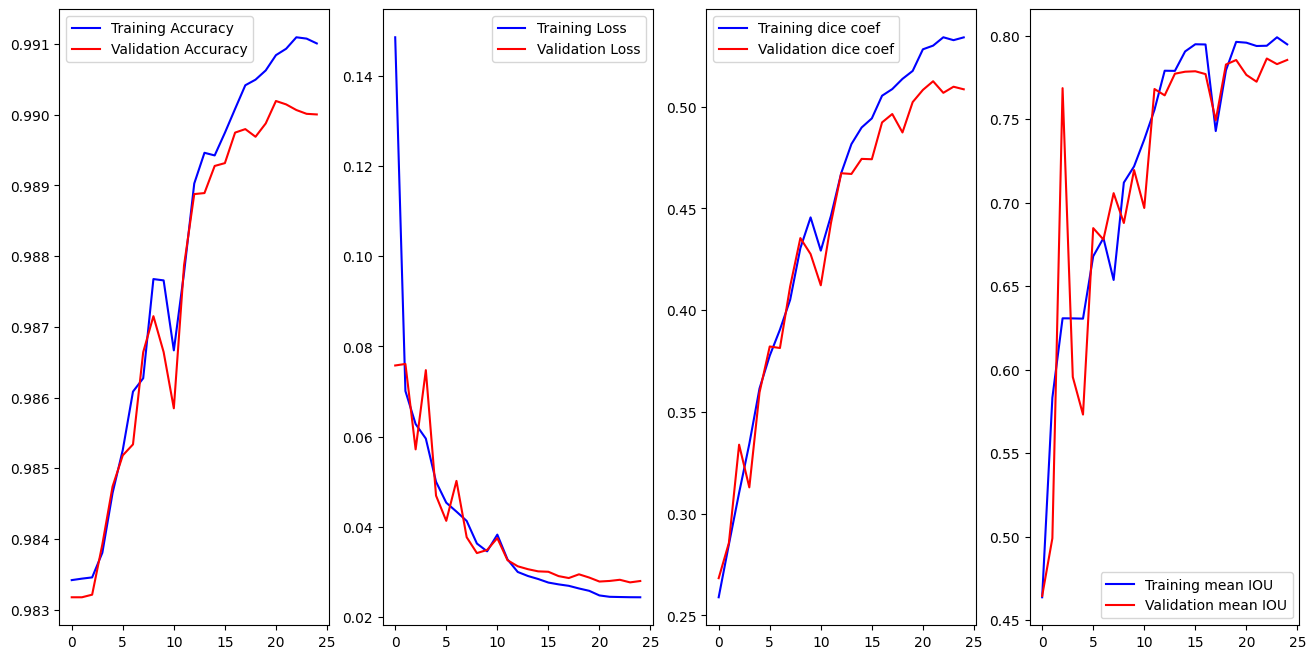

In [ ]:
hist = pd.read_csv('/content/drive/MyDrive/AUNet/training.log', sep=',', engine='c')

acc=hist["accuracy"]
val_acc=hist['val_accuracy']

epoch=range(len(acc))

loss=hist['loss']
val_loss=hist['val_loss']

train_dice=hist['dice_coef']
val_dice=hist['val_dice_coef']

f,ax=plt.subplots(1,4,figsize=(16,8))

ax[0].plot(epoch,acc,'b',label='Training Accuracy')
ax[0].plot(epoch,val_acc,'r',label='Validation Accuracy')
ax[0].legend()

ax[1].plot(epoch,loss,'b',label='Training Loss')
ax[1].plot(epoch,val_loss,'r',label='Validation Loss')
ax[1].legend()

ax[2].plot(epoch,train_dice,'b',label='Training dice coef')
ax[2].plot(epoch,val_dice,'r',label='Validation dice coef')
ax[2].legend()

ax[3].plot(epoch,hist['mean_io_u'],'b',label='Training mean IOU')
ax[3].plot(epoch,hist['val_mean_io_u'],'r',label='Validation mean IOU')
ax[3].legend()

plt.savefig('training_plots.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import os
for f in os.listdir('/content'):
    if f.endswith('.weights.h5'):
        print(f)

model_.09-0.034178.weights.h5
model_.14-0.030606.weights.h5
model_.05-0.046910.weights.h5
model_.15-0.030128.weights.h5
model_.13-0.031254.weights.h5
model_.06-0.041327.weights.h5
model_.01-0.075770.weights.h5
model_.16-0.030036.weights.h5
model_.08-0.037694.weights.h5
model_.24-0.027683.weights.h5
model_.21-0.027871.weights.h5
model_.03-0.057171.weights.h5
model_.17-0.029073.weights.h5
model_.18-0.028646.weights.h5
model_.12-0.032596.weights.h5


In [ ]:
def imageLoader(path):
    image = nib.load(path).get_fdata()
    X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
    for j in range(VOLUME_SLICES):
        X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(image[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
        X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));

        y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT];
    return np.array(image)

def loadDataFromDir(path, list_of_files, mriType, n_images):
    scans = []
    masks = []
    for i in list_of_files[:n_images]:
        fullPath = glob.glob( i + '/*'+ mriType +'*')[0]
        currentScanVolume = imageLoader(fullPath)
        currentMaskVolume = imageLoader( glob.glob( i + '/*seg*')[0] )
        # for each slice in 3D volume, find also it's mask
        for j in range(0, currentScanVolume.shape[2]):
            scan_img = cv2.resize(currentScanVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            mask_img = cv2.resize(currentMaskVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            scans.append(scan_img[..., np.newaxis])
            masks.append(mask_img[..., np.newaxis])

    return np.array(scans, dtype='float32'), np.array(masks, dtype='float32')

def predictByPath(case_path, case):
    # Create input array for 4 modalities
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 4))

    # Load each modality
    t1_path = os.path.join(case_path, f'{case}_t1.nii')
    t1ce_path  = os.path.join(case_path, f'{case}_t1ce.nii')
    t2_path    = os.path.join(case_path, f'{case}_t2.nii')
    flair_path = os.path.join(case_path, f'{case}_flair.nii')

    t1    = nib.load(t1_path).get_fdata()
    t1ce  = nib.load(t1ce_path).get_fdata()
    t2    = nib.load(t2_path).get_fdata()
    flair = nib.load(flair_path).get_fdata()

    for j in range(VOLUME_SLICES):
        slice_index = j + VOLUME_START_AT
        X[j, :, :, 0] = cv2.resize(t1[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 1] = cv2.resize(t1ce[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 2] = cv2.resize(t2[:, :, slice_index], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 3] = cv2.resize(flair[:, :, slice_index], (IMG_SIZE, IMG_SIZE))

    # Normalize the input before prediction
    X_norm = X / np.max(X)
    return model.predict(X_norm, verbose=1)

def showPredictsById(case, start_slice=60):
    path = f"/content/drive/MyDrive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/{case}"

    # Load ground truth segmentation
    gt = nib.load(os.path.join(path, f'{case}_seg.nii')).get_fdata()

    # Load all four modalities
    t1 = nib.load(os.path.join(path, f'{case}_t1.nii')).get_fdata()
    t1ce  = nib.load(os.path.join(path, f'{case}_t1ce.nii')).get_fdata()
    t2    = nib.load(os.path.join(path, f'{case}_t2.nii')).get_fdata()
    flair = nib.load(os.path.join(path, f'{case}_flair.nii')).get_fdata()

    # Get predicted segmentation from your predictByPath function
    p = predictByPath(path, case)

    # Extract predicted segmentation channels
    core = p[:,:,:,1]
    edema = p[:,:,:,2]
    enhancing = p[:,:,:,3]

    # Determine slice indices
    slice_idx = start_slice + VOLUME_START_AT  # for the original modalities and GT
    # For predictions, we assume p has VOLUME_SLICES slices; here we use start_slice index.

    # Create a figure with 2 rows and 5 columns
    fig, axs = plt.subplots(2, 5, figsize=(25, 10))

    # Row 0: Original modalities
    axs[0, 0].imshow(cv2.resize(t1[:, :, slice_idx], (IMG_SIZE, IMG_SIZE)), cmap='gray', interpolation='none')
    axs[0, 0].set_title('Original T1')

    axs[0, 1].imshow(cv2.resize(t1ce[:, :, slice_idx], (IMG_SIZE, IMG_SIZE)), cmap='gray', interpolation='none')
    axs[0, 1].set_title('Original T1ce')

    axs[0, 2].imshow(cv2.resize(t2[:, :, slice_idx], (IMG_SIZE, IMG_SIZE)), cmap='gray', interpolation='none')
    axs[0, 2].set_title('Original T2')

    axs[0, 3].imshow(cv2.resize(flair[:, :, slice_idx], (IMG_SIZE, IMG_SIZE)), cmap='gray', interpolation='none')
    axs[0, 3].set_title('Original FLAIR')

    # Leave the 5th subplot empty or use it for a montage if desired.
    axs[0, 4].axis('off')

    # Row 1: Ground truth and predictions
    curr_gt = cv2.resize(gt[:, :, slice_idx], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    axs[1, 0].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.5)
    axs[1, 0].set_title('Ground Truth')

    # For aggregated predicted segmentation, you can show the argmax across channels.
    pred_seg = np.argmax(p, axis=-1)
    pred_seg_slice = cv2.resize(pred_seg[start_slice, :, :], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    axs[1, 1].imshow(pred_seg_slice, cmap="jet", interpolation='none', alpha=0.5)
    axs[1, 1].set_title('Predicted Segmentation')

    axs[1, 2].imshow(cv2.resize(edema[start_slice, :, :], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST), cmap="OrRd", alpha=0.5)
    axs[1, 2].set_title(f'{SEGMENT_CLASSES[1]} predicted')

    axs[1, 3].imshow(cv2.resize(core[start_slice, :, :], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST), cmap="OrRd", alpha=0.5)
    axs[1, 3].set_title(f'{SEGMENT_CLASSES[2]} predicted')

    axs[1, 4].imshow(cv2.resize(enhancing[start_slice, :, :], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST), cmap="OrRd", alpha=0.5)
    axs[1, 4].set_title(f'{SEGMENT_CLASSES[3]} predicted')

    plt.tight_layout()
    plt.savefig('all_modalities_slice_sample.png', dpi=300, bbox_inches='tight')
    plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 541ms/step


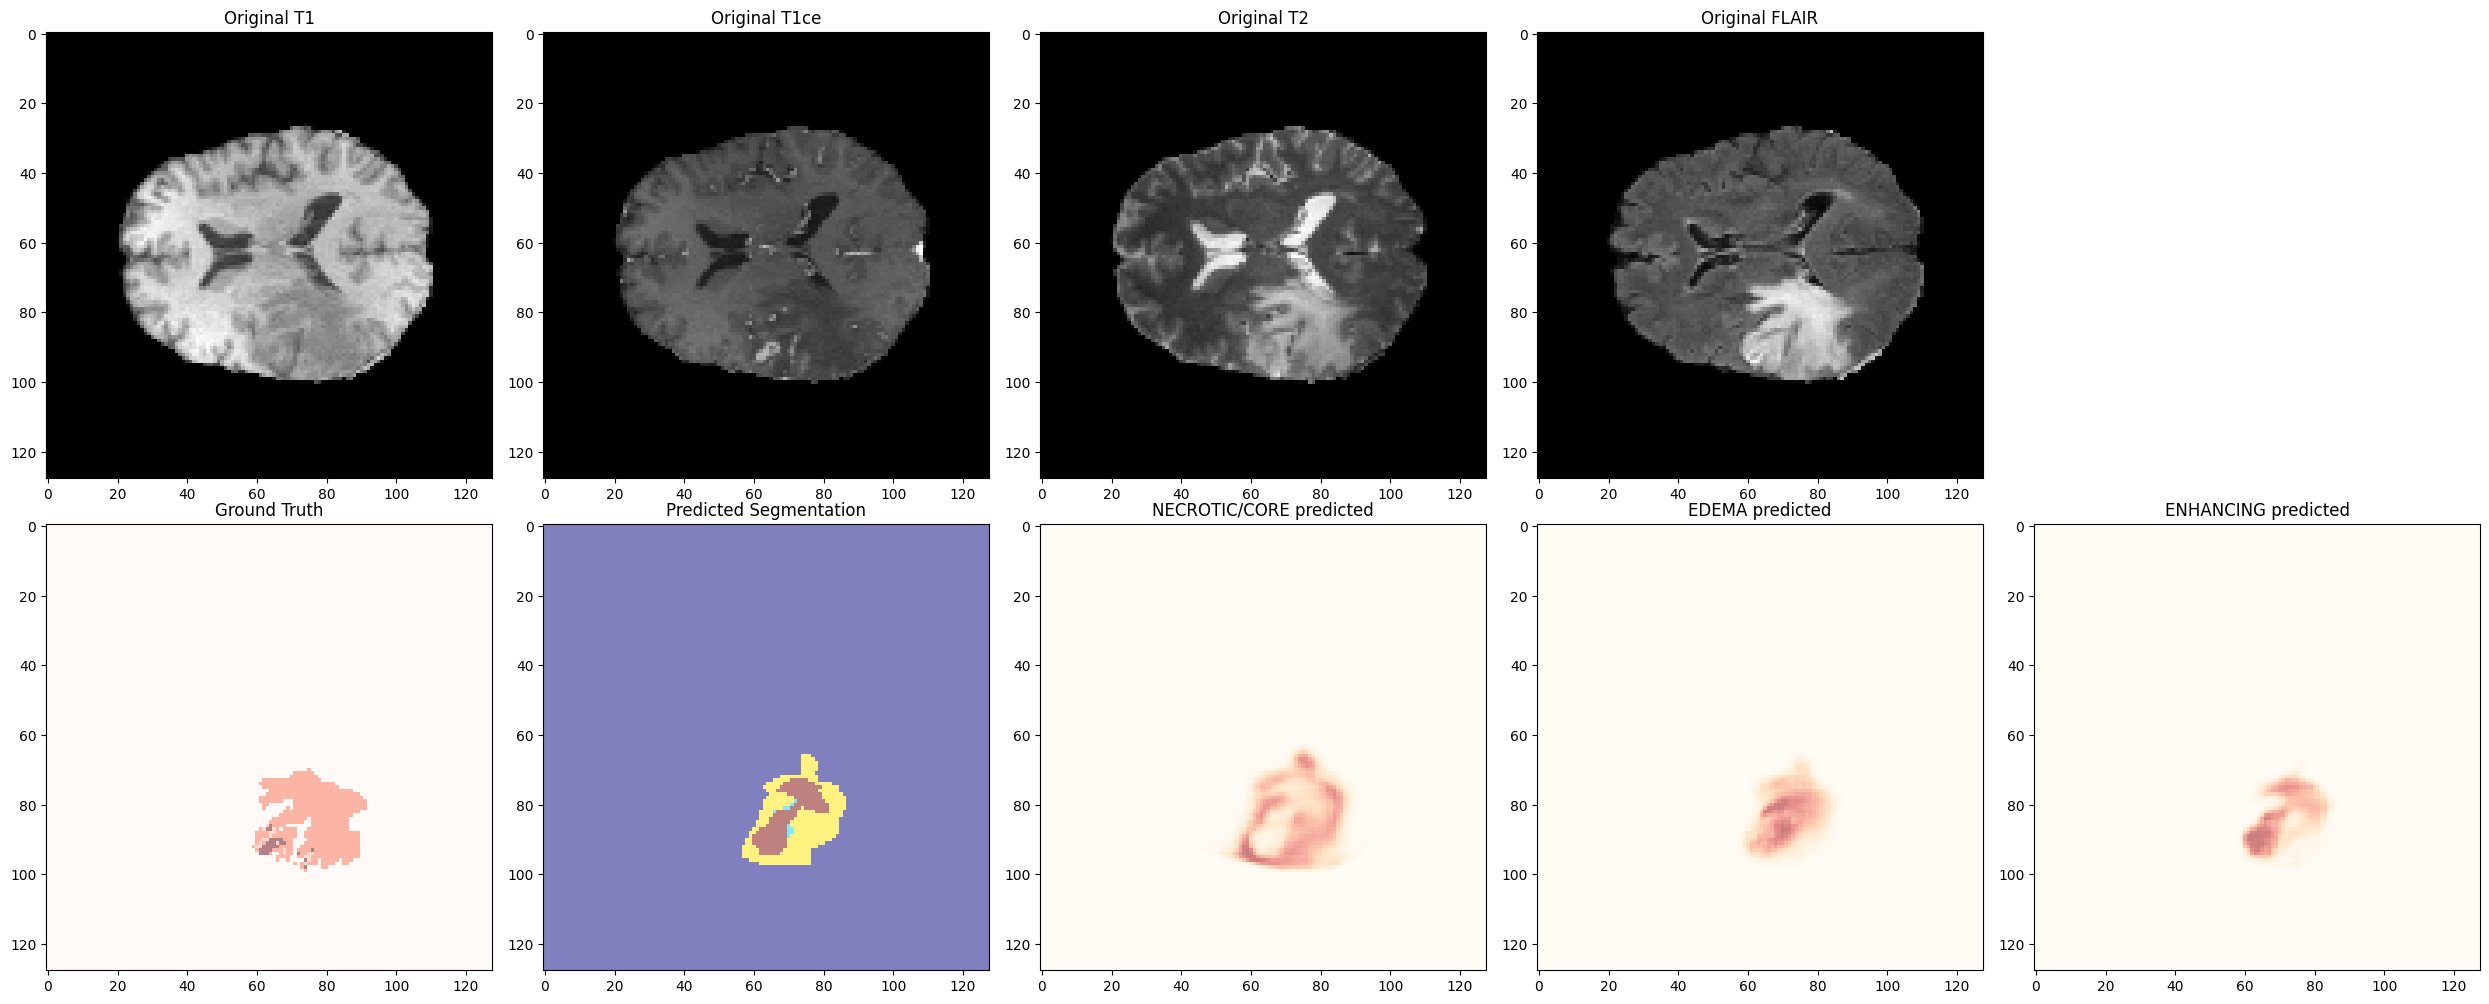

In [ ]:
showPredictsById(case=test_ids[10])

In [ ]:
# Evaluate the model on the test data
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    metrics=[
        'accuracy',
        tf.keras.metrics.MeanIoU(num_classes=4),
        DiceCoefMetric(),
        PrecisionMetric(),
        SensitivityMetric(),
        SpecificityMetric(),
        DiceCoefNecroticMetric(),
        DiceCoefEdemaMetric(),
        DiceCoefEnhancingMetric()
    ]
)

# Evaluate the model on the test data
results = model.evaluate(test_generator, batch_size=100, callbacks=callbacks)

descriptions = [
    "Loss", "Accuracy", "MeanIOU", "Dice coefficient",
    "Precision", "Sensitivity", "Specificity",
    "Dice coef Necrotic", "Dice coef Edema", "Dice coef Enhancing"
]

# Combine results
print("\nModel evaluation on the test set:")
print("==================================")
for metric, description in zip(results, descriptions):
    print(f"{description} : {round(metric, 4)}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 318s 29s/step - accuracy: 0.9906 - dice_coef: 0.5371 - dice_coef_edema: 0.6736 - dice_coef_enhancing: 0.5956 - dice_coef_necrotic: 0.4685 - loss: 0.0268 - mean_io_u_3: 0.7797 - precision: 0.9934 - sensitivity: 0.9871 - specificity: 0.9977

Model evaluation on the test set:
Loss : 0.0303
Accuracy : 0.9894
MeanIOU : 0.779
Dice coefficient : 0.5252
Precision : 0.9925
Sensitivity : 0.9853
Specificity : 0.9974
Dice coef Necrotic : 0.4537
Dice coef Edema : 0.673
Dice coef Enhancing : 0.5609


In [ ]:
# Voxel spacing
def compute_tumor_volumes(segmentation, voxel_spacing=(1.0, 1.0, 1.0)):
    voxel_volume_mm3 = np.prod(voxel_spacing)
    volumes = {}
    total_voxels = 0

    for label, name in zip([1, 2, 3], ['core', 'edema', 'enhancing']):
        count = np.sum(segmentation == label)
        volumes[name] = {
            "voxel_count": int(count),
            "volume_mm3": float(count * voxel_volume_mm3)
        }
        total_voxels += count

    volumes["total"] = {
        "voxel_count": int(total_voxels),
        "volume_mm3": float(total_voxels * voxel_volume_mm3)
    }
    return volumes

# Class presence
def get_class_presence(segmentation):
    return {
        "core": np.any(segmentation == 1),
        "edema": np.any(segmentation == 2),
        "enhancing": np.any(segmentation == 3)
    }

# Location
def estimate_location(segmentation):
    coords = np.argwhere(segmentation > 0)
    center = coords.mean(axis=0)  # (z, y, x)
    midline_x = segmentation.shape[0] // 2

    hemisphere = "Left" if center[0] < midline_x else "Right"
    if abs(center[0] - midline_x) < 10:  # ~symmetric
        hemisphere = "Bilateral"

    return {
        "hemisphere": hemisphere,
        "approx_center_voxel": tuple(np.round(center).astype(int))
    }

# Center of mass and cross-sectional area
def segmentation_summary(segmentation):
    summary = {}
    for label, name in zip([1, 2, 3], ['core', 'edema', 'enhancing']):
        binary_mask = segmentation == label
        labeled, num_components = ndi.label(binary_mask)
        com = ndi.center_of_mass(binary_mask) if np.any(binary_mask) else (None, None, None)
        slices = ndi.find_objects(labeled)
        max_area = 0
        for sl in slices:
            if sl is not None:
                area = np.prod([s.stop - s.start for s in sl])
                max_area = max(max_area, area)

        summary[name] = {
            "components": num_components,
            "center_of_mass": com,
            "max_cross_sectional_area_voxels": max_area
        }
    return summary

def describe_radiological_features(segmentation):
    features = {}

    if np.any(segmentation == 2):  # Edema
        features["mass_effect"] = "Possible mass effect due to large edema"
    if np.any(segmentation == 3):  # Enhancing
        features["contrast_enhancement"] = "Enhancing regions observed (suggests active tumor)"
    if np.any(segmentation == 1):
        features["irregularity"] = "Non-enhancing core present, possibly necrotic"

    center = estimate_location(segmentation)["hemisphere"]
    features["laterality"] = f"{center} hemisphere involvement"

    return features

In [ ]:
# Constants
VOLUME_SLICES = 100
VOLUME_START_AT = 22
IMG_SIZE = 128

def analyze_patient(case_id, base_path):
    case_dir = os.path.join(base_path, f"BraTS20_Training_{case_id}")

    # Load predicted segmentation
    pred = predictByPath(case_dir, f"BraTS20_Training_{case_id}")
    seg_pred = np.argmax(pred, axis=-1)

    # Resize prediction to original shape (240, 240)
    seg_pred_resized = np.zeros((seg_pred.shape[0], 240, 240), dtype=np.uint8)
    for i in range(seg_pred.shape[0]):
        seg_pred_resized[i] = cv2.resize(seg_pred[i], (240, 240), interpolation=cv2.INTER_NEAREST)
    seg_pred_resized = np.transpose(seg_pred_resized, (1, 2, 0))  # (H, W, D)

    # Load ground truth segmentation
    gt_path = os.path.join(case_dir, f"BraTS20_Training_{case_id}_seg.nii")
    gt_img = nib.load(gt_path)
    seg_gt = gt_img.get_fdata().astype(np.uint8)
    spacing = gt_img.header.get_zooms()[:3]  # Real voxel spacing

    # Run analysis on both GT and prediction
    result = {
        "case": case_id,
        "spacing_mm": spacing,
        "ground_truth": {
            "volumes": compute_tumor_volumes(seg_gt, spacing),
            "presence": get_class_presence(seg_gt),
            "location": estimate_location(seg_gt),
            "summary": segmentation_summary(seg_gt),
            "radiology_features": describe_radiological_features(seg_gt)
        },
        "prediction": {
            "volumes": compute_tumor_volumes(seg_pred_resized, spacing),
            "presence": get_class_presence(seg_pred_resized),
            "location": estimate_location(seg_pred_resized),
            "summary": segmentation_summary(seg_pred_resized),
            "radiology_features": describe_radiological_features(seg_pred_resized)
        }
    }

    return result

In [ ]:
test_results = []
base_path = "/content/drive/MyDrive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

for test_id in test_ids:
    case_id = test_id.split("_")[-1]
    print(f"Processing case: {case_id}")
    result = analyze_patient(case_id, base_path)
    test_results.append(result)

Processing case: 359
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 341ms/step
Processing case: 235
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 057
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 117
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 222
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 210
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 026
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 143
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 040
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 017
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 067
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 328
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


<ipython-input-47-502627dcbfdb>:33: RuntimeWarning: Mean of empty slice.
  center = coords.mean(axis=0)  # (z, y, x)
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
<ipython-input-47-502627dcbfdb>:42: RuntimeWarning: invalid value encountered in cast
  "approx_center_voxel": tuple(np.round(center).astype(int))


Processing case: 285
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 335
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 095
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 094
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 312
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 334
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 031
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 155
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 065
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 075
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 227
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 073
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 109
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 058
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 076
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 280
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 110
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/st

In [ ]:
# Define output path
csv_path = "/content/drive/MyDrive/AUNet/test_results_summary.csv"

# Flatten
flattened_results = []

for result in test_results:
    case_id = result["case"]
    spacing = result["spacing_mm"]

    for mode in ["ground_truth", "prediction"]:
        res = result[mode]
        entry = {
            "case": case_id,
            "type": mode,
            "spacing_x": spacing[0],
            "spacing_y": spacing[1],
            "spacing_z": spacing[2],

            # Volumes
            "vol_core": res["volumes"]["core"]["volume_mm3"],
            "vol_edema": res["volumes"]["edema"]["volume_mm3"],
            "vol_enhancing": res["volumes"]["enhancing"]["volume_mm3"],
            "vol_total": res["volumes"]["total"]["volume_mm3"],

            # Presence
            "has_core": res["presence"]["core"],
            "has_edema": res["presence"]["edema"],
            "has_enhancing": res["presence"]["enhancing"],

            # Location
            "hemisphere": res["location"]["hemisphere"],
            "center_voxel": str(res["location"]["approx_center_voxel"]),

            # Radiological Features
            "mass_effect": res["radiology_features"].get("mass_effect", ""),
            "contrast_enhancement": res["radiology_features"].get("contrast_enhancement", ""),
            "irregularity": res["radiology_features"].get("irregularity", ""),
            "laterality": res["radiology_features"].get("laterality", ""),

            # Tumor summary
            "core_components": res["summary"]["core"]["components"],
            "core_com": str(res["summary"]["core"]["center_of_mass"]),
            "core_max_area": res["summary"]["core"]["max_cross_sectional_area_voxels"],

            "edema_components": res["summary"]["edema"]["components"],
            "edema_com": str(res["summary"]["edema"]["center_of_mass"]),
            "edema_max_area": res["summary"]["edema"]["max_cross_sectional_area_voxels"],

            "enhancing_components": res["summary"]["enhancing"]["components"],
            "enhancing_com": str(res["summary"]["enhancing"]["center_of_mass"]),
            "enhancing_max_area": res["summary"]["enhancing"]["max_cross_sectional_area_voxels"],
        }
        flattened_results.append(entry)

# Write to csv
keys = flattened_results[0].keys()

with open(csv_path, "w", newline='') as output_file:
    dict_writer = csv.DictWriter(output_file, keys)
    dict_writer.writeheader()
    dict_writer.writerows(flattened_results)

In [ ]:
from skimage.util import montage as sk_montage

def save_t1ce_montage(t1ce_volume, case_id, out_dir="/content/drive/MyDrive/AUNet/Montages/"):
    os.makedirs(out_dir, exist_ok=True)

    t1ce_crop = t1ce_volume[:, :, VOLUME_START_AT:VOLUME_START_AT + VOLUME_SLICES]
    t1ce_resized = np.zeros((IMG_SIZE, IMG_SIZE, VOLUME_SLICES))

    for i in range(VOLUME_SLICES):
        t1ce_resized[:, :, i] = cv2.resize(t1ce_crop[:, :, i], (IMG_SIZE, IMG_SIZE))

    montage_img = sk_montage(t1ce_resized, fill=0)
    filename = os.path.join(out_dir, f"{case_id}_t1ce_montage.png")

    plt.figure(figsize=(10, 10))
    plt.imshow(montage_img, cmap="gray")
    plt.axis("off")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    return filename

def save_prediction_montage(segmentation, case_id, out_dir="/content/drive/MyDrive/AUNet/Montages/"):
    os.makedirs(out_dir, exist_ok=True)

    # Resize and normalize for color mapping
    resized = np.zeros((IMG_SIZE, IMG_SIZE, segmentation.shape[0]))
    for i in range(segmentation.shape[0]):
        resized[:, :, i] = cv2.resize(segmentation[i], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    montage_img = sk_montage(resized, fill=0)
    cmap = matplotlib.colormaps["jet"]
    norm = mcolors.Normalize(vmin=np.min(montage_img), vmax=np.max(montage_img))

    filename = os.path.join(out_dir, f"{case_id}_prediction_montage.png")

    plt.figure(figsize=(10, 10))
    plt.imshow(montage_img, cmap=cmap, norm=norm)
    plt.axis("off")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    return filename

In [ ]:
# Initialize lists to store everything
all_cases_info = []

# Define base path
base_path = "/content/drive/MyDrive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

# Loop over all cases in test_results
for result in test_results:
    case_id = result["case"]
    print(f"Processing case: {case_id}")

    try:
        # Load t1ce image
        t1ce_path = os.path.join(base_path, f"BraTS20_Training_{case_id}", f"BraTS20_Training_{case_id}_t1ce.nii")
        t1ce = nib.load(t1ce_path).get_fdata()

        # Get predicted segmentation
        pred = np.argmax(predictByPath(os.path.join(base_path, f"BraTS20_Training_{case_id}"), f'BraTS20_Training_{case_id}'), axis=-1)
        pred_resized = np.zeros((pred.shape[0], 240, 240), dtype=np.uint8)
        for i in range(pred.shape[0]):
            pred_resized[i] = cv2.resize(pred[i], (240, 240), interpolation=cv2.INTER_NEAREST)
        pred_resized = np.transpose(pred_resized, (1, 2, 0))

        # Save montages
        t1ce_img_path = save_t1ce_montage(t1ce, case_id)
        pred_img_path = save_prediction_montage(pred_resized, case_id)


Processing case: 359
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 235
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 057
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 117
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 222
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 210
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 026
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 143
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Processing case: 040
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 017
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 067
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Processing case: 328
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 285
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 335
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 095
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Processing case: 094
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/st